# Skin Lesion Bias Reduction — cGAN training (Colab)

Trains the conditional DCGAN-style GAN at `src/train.py` on Fitzpatrick17k using a Colab GPU.

**Order of operations**
1. Confirm GPU + mount Drive
2. Point the notebook at your code + data
3. Cache images locally for fast IO
4. Pull the latest repo from `origin/main`
5. Install dependencies
6. *(optional)* Run segmentation-aware preprocessing (cv2 / SAM2 / MedSAM3)
7. Configure cGAN hyperparameters
8. Train the cGAN
9. *(optional)* Resume from a checkpoint
10. Watch progress in TensorBoard
11. Generate synthetic samples for underrepresented (FST 5/6) cells

## 1. Verify GPU and Colab environment

In [1]:
import sys

IN_COLAB = "google.colab" in sys.modules
print("Colab:", IN_COLAB)

import torch
print("torch:", torch.__version__, "cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    !nvidia-smi --query-gpu=name,memory.total,memory.free --format=csv

Colab: True
torch: 2.10.0+cu128 cuda available: True
GPU: NVIDIA A100-SXM4-40GB
name, memory.total [MiB], memory.free [MiB]
NVIDIA A100-SXM4-40GB, 40960 MiB, 40437 MiB


## 2. Connect your code and data

Edit `PROJECT_ROOT`, `DATASET_CSV`, and `IMAGE_DIR` to match where the repo and dataset live on your Drive. The paths below assume the same layout as `colab_training.ipynb`.

In [2]:
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
from pathlib import Path

# === EDIT THESE ===
PROJECT_ROOT = Path("/content/drive/MyDrive/SkinLesionBiasReduction")
IMAGE_DIR    = PROJECT_ROOT / "dataset/images"
DATASET_CSV  = PROJECT_ROOT / "dataset/fitzpatrick17k_cleaned.csv"
# ==================

print("PROJECT_ROOT:", PROJECT_ROOT, "exists:", PROJECT_ROOT.exists())
print("IMAGE_DIR:   ", IMAGE_DIR,    "exists:", IMAGE_DIR.exists())
print("DATASET_CSV: ", DATASET_CSV,  "exists:", DATASET_CSV.exists())
assert PROJECT_ROOT.exists(), f"PROJECT_ROOT does not exist: {PROJECT_ROOT}"
assert IMAGE_DIR.exists(),    f"IMAGE_DIR does not exist:    {IMAGE_DIR}"
assert DATASET_CSV.exists(),  f"DATASET_CSV does not exist:  {DATASET_CSV}"

%cd $PROJECT_ROOT

PROJECT_ROOT: /content/drive/MyDrive/SkinLesionBiasReduction exists: True
IMAGE_DIR:    /content/drive/MyDrive/SkinLesionBiasReduction/dataset/images exists: True
DATASET_CSV:  /content/drive/MyDrive/SkinLesionBiasReduction/dataset/fitzpatrick17k_cleaned.csv exists: True
/content/drive/MyDrive/SkinLesionBiasReduction


### 2.1 Cache the images on local disk

Reading 16k JPEGs through Drive's FUSE mount is the throughput bottleneck on Colab. Copy them once to `/content/local_images` (parallel `cp -n`, resumable) and point the trainer at the local copy. The dataset CSV stays on Drive — it's a single small file.

In [4]:
import subprocess, time

DRIVE_IMAGE_DIR = IMAGE_DIR
LOCAL_IMAGE_DIR = Path("/content/local_images")
LOCAL_IMAGE_DIR.mkdir(parents=True, exist_ok=True)

def _count_files(d):
    r = subprocess.run(f"ls -1 '{d}' 2>/dev/null | wc -l",
                       shell=True, capture_output=True, text=True)
    return int(r.stdout.strip() or 0)

n_source = _count_files(DRIVE_IMAGE_DIR)
n_local  = _count_files(LOCAL_IMAGE_DIR)
print(f"Drive: {n_source} files | Local: {n_local} files "
      f"(need ~{max(0, n_source - n_local)} more)")

if n_local >= n_source > 0:
    print("Local cache is complete — skipping copy.")
else:
    print("Parallel-copying from Drive (64 workers)...")
    t0 = time.time()
    cmd = (
        f"cd '{DRIVE_IMAGE_DIR}' && "
        f"find . -maxdepth 1 -type f -print0 | "
        f"xargs -0 -n 64 -P 64 cp -n -t '{LOCAL_IMAGE_DIR}/'"
    )
    subprocess.run(cmd, shell=True, check=True)
    n_local = _count_files(LOCAL_IMAGE_DIR)
    print(f"Done in {time.time()-t0:.1f}s — local now has {n_local} files.")

# Use the local cache for training
TRAIN_IMAGE_DIR = LOCAL_IMAGE_DIR

Drive: 16518 files | Local: 0 files (need ~16518 more)
Parallel-copying from Drive (64 workers)...
Done in 436.9s — local now has 16518 files.


### 2.2 Pull the latest repo state

Discards local edits in the Drive checkout and resets to `origin/main`. Skip this cell if you have uncommitted work on Drive you don't want overwritten.

In [5]:
!git fetch origin main && git reset --hard origin/main

From https://github.com/hoangnam310/SkinLesionBiasReduction
 * branch            main       -> FETCH_HEAD
Updating files: 100% (47/47), done.
HEAD is now at a61762b Chage the model architecture


## 3. Install dependencies

Colab images already include `torch`, `torchvision`, `numpy`, `pandas`, `Pillow`, `tqdm`, `matplotlib`, `scipy`, and `tensorboard`. The cGAN trainer uses only those — no extra installs needed. The cell below is a no-op safety net in case Colab ever ships a slimmer image.

In [6]:
!pip install --quiet 'tensorboard' 'scipy'

## 4. (Optional) Train on a pre-segmented dataset

If you already built segmented copies of Fitzpatrick17k (the cv2 / SAM2 / SAM3 / MedSAM3 outputs from `colab_training.ipynb` section 6, sitting on Drive at `dataset/images_<backend>_224/`), set `SEG_VARIANT` below to swap them in. The cell mirrors the chosen Drive dir to local disk for IO speed and rebinds `TRAIN_IMAGE_DIR` so the training cell picks it up automatically. Leave `SEG_VARIANT = "none"` to train on the raw images.

In [7]:
SEG_VARIANT = "none"  # "none" | "cv2" | "sam2" | "sam3" | "medsam3"

# Drive paths produced by colab_training.ipynb section 6.
DRIVE_CV2_DIR     = PROJECT_ROOT / "dataset/images_cv2_224"
DRIVE_SAM2_DIR    = PROJECT_ROOT / "dataset/images_sam2_224"
DRIVE_SAM3_DIR    = PROJECT_ROOT / "dataset/images_sam3_224"
DRIVE_MEDSAM3_DIR = PROJECT_ROOT / "dataset/images_medsam3_224"

# Local mirrors (fast IO during training).
LOCAL_CV2_DIR     = Path("/content/local_images_cv2_224")
LOCAL_SAM2_DIR    = Path("/content/local_images_sam2_224")
LOCAL_SAM3_DIR    = Path("/content/local_images_sam3_224")
LOCAL_MEDSAM3_DIR = Path("/content/local_images_medsam3_224")

SEG_DIRS = {
    "cv2":     (DRIVE_CV2_DIR,     LOCAL_CV2_DIR),
    "sam2":    (DRIVE_SAM2_DIR,    LOCAL_SAM2_DIR),
    "sam3":    (DRIVE_SAM3_DIR,    LOCAL_SAM3_DIR),
    "medsam3": (DRIVE_MEDSAM3_DIR, LOCAL_MEDSAM3_DIR),
}
assert SEG_VARIANT == "none" or SEG_VARIANT in SEG_DIRS, \
    f"SEG_VARIANT must be 'none' or one of {sorted(SEG_DIRS)}, got {SEG_VARIANT!r}"

print(f"SEG_VARIANT = {SEG_VARIANT!r}")
if SEG_VARIANT != "none":
    drive_dir, local_dir = SEG_DIRS[SEG_VARIANT]
    print(f"  Drive: {drive_dir} (exists={drive_dir.exists()})")
    print(f"  Local: {local_dir}")

SEG_VARIANT = 'none'


In [8]:
# Mirror Drive → local for the chosen variant, then rebind TRAIN_IMAGE_DIR so
# section 6's training cell uses the segmented images. Same parallel-cp pattern
# as section 2.1.
import time

if SEG_VARIANT == "none":
    print("SEG_VARIANT='none' — keeping raw images at:", TRAIN_IMAGE_DIR)
else:
    drive_dir, local_dir = SEG_DIRS[SEG_VARIANT]
    assert drive_dir.exists(), f"Drive dir missing: {drive_dir}"
    local_dir.mkdir(parents=True, exist_ok=True)

    n_src = _count_files(drive_dir)
    n_dst = _count_files(local_dir)
    print(f"[{SEG_VARIANT}] Drive: {n_src} files | Local: {n_dst} files "
          f"(need ~{max(0, n_src - n_dst)} more)")

    if n_dst >= n_src > 0:
        print(f"[{SEG_VARIANT}] Local cache complete — skipping copy.")
    else:
        t0 = time.time()
        cmd = (
            f"cd '{drive_dir}' && "
            f"find . -maxdepth 1 -type f -print0 | "
            f"xargs -0 -n 64 -P 64 cp -n -t '{local_dir}/'"
        )
        subprocess.run(cmd, shell=True, check=True)
        n_dst = _count_files(local_dir)
        print(f"[{SEG_VARIANT}] Done — {n_dst} files in {time.time()-t0:.1f}s")

    TRAIN_IMAGE_DIR = local_dir
    print("TRAIN_IMAGE_DIR is now:", TRAIN_IMAGE_DIR)

SEG_VARIANT='none' — keeping raw images at: /content/local_images


## 5. Configure cGAN hyperparameters

Defaults match `src/train.py`. Adjust `EPOCHS` and `BATCH_SIZE` to your GPU:
- T4 (~15 GB): `BATCH_SIZE = 64` is comfortable
- A100 (~40 GB): `BATCH_SIZE = 128`+ if you want faster epochs

Outputs land under `PROJECT_ROOT/outputs/<timestamp>/{checkpoints,samples,logs}`. Keeping outputs on Drive means checkpoints survive a runtime disconnect.

In [ ]:
# EPOCHS              = 200
# BATCH_SIZE          = 64
# LR                  = 2e-4
# BETA1               = 0.5
# BETA2               = 0.999
# LATENT_DIM          = 100
# EMBEDDING_DIM       = 50
# NGF                 = 64
# NDF                 = 64
# LABEL_SMOOTHING     = 0.1
# NOISE_STD           = 0.1
# NOISE_DECAY         = 0.995
# CHECKPOINT_INTERVAL = 10
# SAMPLE_INTERVAL     = 5
# FID_INTERVAL        = 20
# FID_NUM_SAMPLES     = 1000
# NUM_WORKERS         = 4

# OUTPUT_DIR = PROJECT_ROOT / "outputs"
# OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# print("Outputs will land under:", OUTPUT_DIR)

Outputs will land under: /content/drive/MyDrive/SkinLesionBiasReduction/outputs


## 6. Train the cGAN

Logs go to stdout *and* TensorBoard. A new `outputs/<YYYYMMDD_HHMMSS>/` directory is created at start; record its name from the first few lines of output if you want to resume later.

> **Smoke test:** set `EPOCHS = 1` (and optionally `FID_INTERVAL = 0`) to verify the pipeline before committing to a 200-epoch run.

In [ ]:
# !python src/train.py \
#     --csv_path "{DATASET_CSV}" \
#     --image_dir "{TRAIN_IMAGE_DIR}" \
#     --epochs {EPOCHS} \
#     --batch_size {BATCH_SIZE} \
#     --lr {LR} \
#     --beta1 {BETA1} \
#     --beta2 {BETA2} \
#     --latent_dim {LATENT_DIM} \
#     --embedding_dim {EMBEDDING_DIM} \
#     --ngf {NGF} \
#     --ndf {NDF} \
#     --label_smoothing {LABEL_SMOOTHING} \
#     --noise_std {NOISE_STD} \
#     --noise_decay {NOISE_DECAY} \
#     --checkpoint_interval {CHECKPOINT_INTERVAL} \
#     --sample_interval {SAMPLE_INTERVAL} \
#     --fid_interval {FID_INTERVAL} \
#     --fid_num_samples {FID_NUM_SAMPLES} \
#     --num_workers {NUM_WORKERS} \
#     --output_dir "{OUTPUT_DIR}" \
#     --device cuda

2026-05-02 17:45:54.138916: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-02 17:45:54.156433: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777743954.178433    4300 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777743954.185686    4300 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777743954.204329    4300 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## 6.5 Train the WGAN-GP variant (`src/train_wgan.py`)

Tests the new training pipeline: Wasserstein loss with gradient penalty (λ=10), `n_critic=5` critic updates per generator update, DiffAugment (color + translation + cutout) on real / fake / interpolated, and the `Upsample+Conv2d` generator that replaces stride-2 ConvTranspose2d to remove checkerboard artifacts. Adam(β₁=0, β₂=0.9) is the WGAN-GP-standard optimizer setting.

Outputs land under `OUTPUT_DIR/wgan_<YYYYMMDD_HHMMSS>/{checkpoints,samples,logs}` — the `wgan_` prefix keeps these runs separate from the original DCGAN runs above so TensorBoard and checkpoint discovery (sections 8–10) still work without modification.

> **Smoke test first:** set `WGAN_EPOCHS = 1` and `WGAN_FID_INTERVAL = 0` to confirm the pipeline executes (gradient penalty, DiffAugment, n_critic loop, checkpointing) before committing to a long run.

In [ ]:
# Smoke test defaults: WGAN_EPOCHS = 1 and WGAN_FID_INTERVAL = 0 to verify the
# pipeline first; bump epochs and re-enable FID for a real run.
WGAN_EPOCHS              = 200
WGAN_BATCH_SIZE          = 64
WGAN_LR_G                = 1e-4
WGAN_LR_C                = 1e-4
WGAN_BETA1               = 0.0
WGAN_BETA2               = 0.9
WGAN_N_CRITIC            = 5
WGAN_LAMBDA_GP           = 10.0
WGAN_DIFFAUG_POLICY      = "color,translation,cutout"
WGAN_GEN_ARCH            = "upsample"   # "upsample" (Upsample+Conv) | "deconv" (ConvTranspose2d)
WGAN_LATENT_DIM          = 100
WGAN_EMBEDDING_DIM       = 50
WGAN_NGF                 = 64
WGAN_NDF                 = 64
WGAN_CHECKPOINT_INTERVAL = 10
WGAN_SAMPLE_INTERVAL     = 5
WGAN_FID_INTERVAL        = 20
WGAN_FID_NUM_SAMPLES     = 1000

print("WGAN-GP outputs land under:", OUTPUT_DIR, "/ wgan_<timestamp>")

In [ ]:
!python src/train_wgan.py \
    --csv_path "{DATASET_CSV}" \
    --image_dir "{TRAIN_IMAGE_DIR}" \
    --epochs {WGAN_EPOCHS} \
    --batch_size {WGAN_BATCH_SIZE} \
    --lr_g {WGAN_LR_G} \
    --lr_c {WGAN_LR_C} \
    --beta1 {WGAN_BETA1} \
    --beta2 {WGAN_BETA2} \
    --n_critic {WGAN_N_CRITIC} \
    --lambda_gp {WGAN_LAMBDA_GP} \
    --diffaug_policy "{WGAN_DIFFAUG_POLICY}" \
    --gen_arch {WGAN_GEN_ARCH} \
    --latent_dim {WGAN_LATENT_DIM} \
    --embedding_dim {WGAN_EMBEDDING_DIM} \
    --ngf {WGAN_NGF} \
    --ndf {WGAN_NDF} \
    --checkpoint_interval {WGAN_CHECKPOINT_INTERVAL} \
    --sample_interval {WGAN_SAMPLE_INTERVAL} \
    --fid_interval {WGAN_FID_INTERVAL} \
    --fid_num_samples {WGAN_FID_NUM_SAMPLES} \
    --num_workers {NUM_WORKERS} \
    --output_dir "{OUTPUT_DIR}" \
    --device cuda

## 7. (Optional) Resume from a checkpoint

`src/train.py --resume <path>` re-hydrates both networks and both optimizers and continues from the saved epoch. Point `RESUME_CKPT` at a `checkpoint_epoch_XXXX.pt` (or `final_model.pt`) under `outputs/<run>/checkpoints/`.

In [11]:
# RESUME_CKPT = OUTPUT_DIR / "20260501_120000/checkpoints/checkpoint_epoch_0040.pt"
# !python src/train.py \
#     --csv_path "{DATASET_CSV}" \
#     --image_dir "{TRAIN_IMAGE_DIR}" \
#     --resume "{RESUME_CKPT}" \
#     --epochs {EPOCHS} \
#     --batch_size {BATCH_SIZE} \
#     --num_workers {NUM_WORKERS} \
#     --output_dir "{OUTPUT_DIR}" \
#     --device cuda

## 8. TensorBoard

Loss curves, D(x) / D(G(z)) traces, sample grids per `SAMPLE_INTERVAL`, and FID per `FID_INTERVAL`.

In [18]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [17]:
%tensorboard --logdir $OUTPUT_DIR

Reusing TensorBoard on port 6006 (pid 27804), started 0:53:46 ago. (Use '!kill 27804' to kill it.)

<IPython.core.display.Javascript object>

## 9. Preview the latest sample grid

Pulls the most recent `samples_epoch_XXXX.png` from the freshest run.

Latest grid: /content/drive/MyDrive/SkinLesionBiasReduction/outputs/20260502_174610/samples/samples_epoch_0200.png


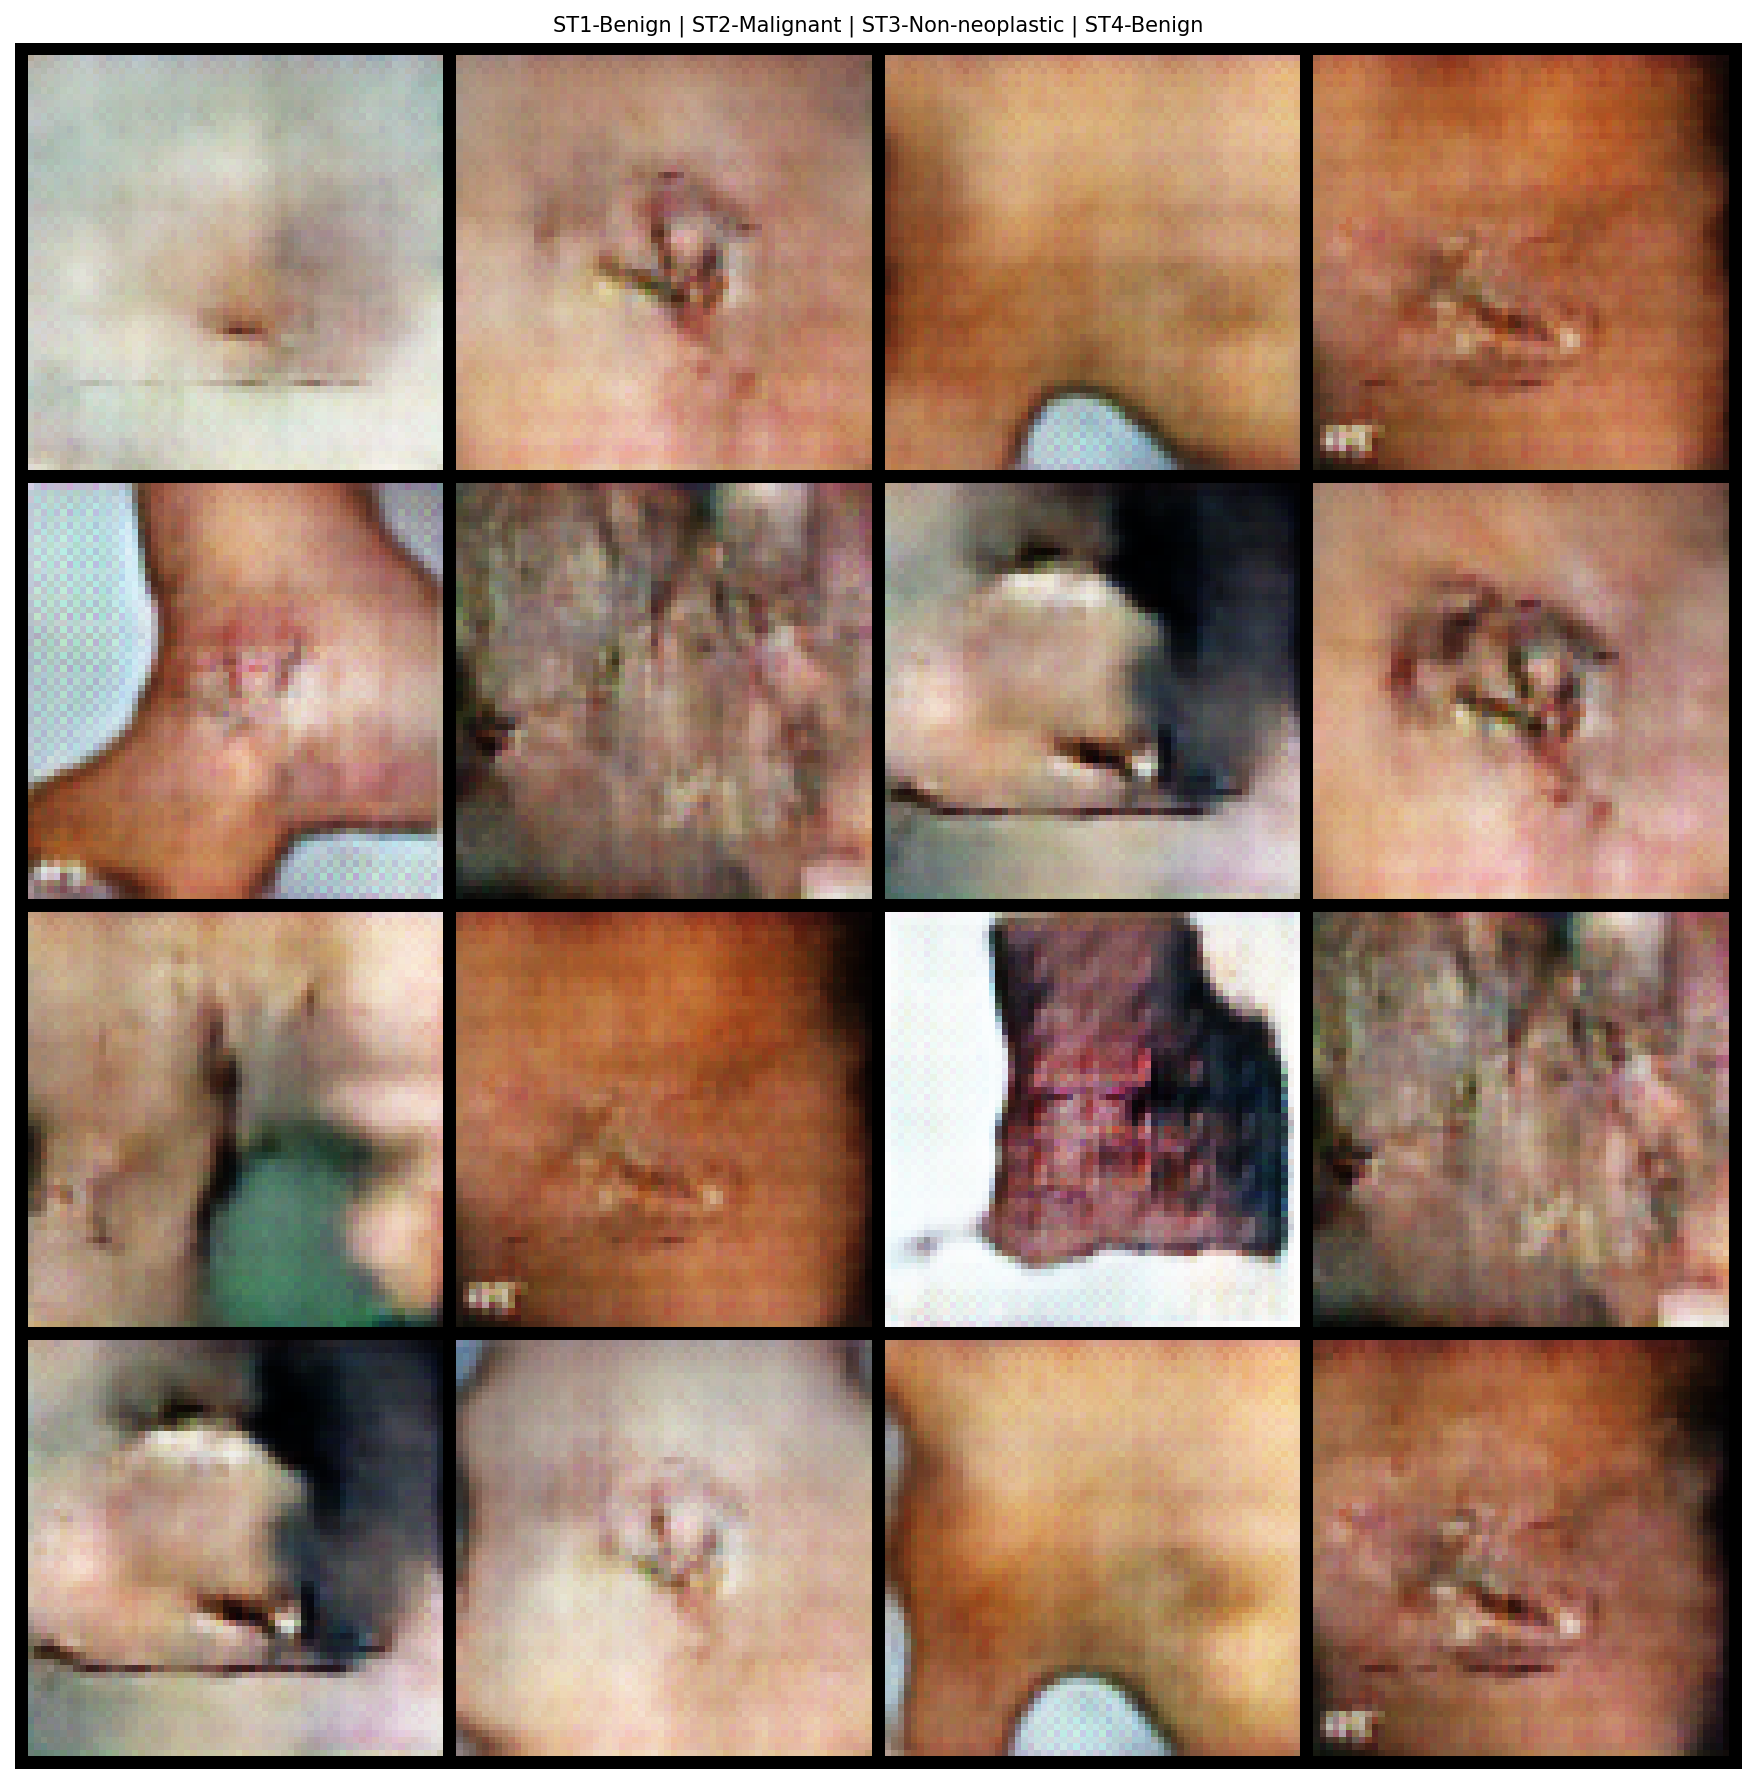

In [14]:
from IPython.display import Image as IPyImage, display

runs = sorted(OUTPUT_DIR.glob("*/samples"), key=lambda p: p.stat().st_mtime, reverse=True)
if not runs:
    print("No samples yet.")
else:
    grids = sorted(runs[0].glob("samples_epoch_*.png"))
    if not grids:
        print(f"No grids in {runs[0]} yet.")
    else:
        latest = grids[-1]
        print("Latest grid:", latest)
        display(IPyImage(filename=str(latest)))

## 10. Generate synthetic images for underrepresented skin tones

After training, point `GEN_CKPT` at the checkpoint you want to sample from and run `src/generate.py`. Defaults below produce 500 images each for FST 5 and FST 6 across all three lesion types, plus a 4×4 preview grid and a metadata CSV that follows the Fitzpatrick17k schema (so it can be merged into a combined dataloader for the downstream classifier).

In [15]:
ckpts = sorted(OUTPUT_DIR.glob("*/checkpoints/*.pt"), key=lambda p: p.stat().st_mtime, reverse=True)
assert ckpts, f"No checkpoints under {OUTPUT_DIR}"
GEN_CKPT = ckpts[0]
print("Generating from:", GEN_CKPT)

GEN_OUTPUT_DIR  = PROJECT_ROOT / "generated_images"
GEN_NUM_SAMPLES = 500
GEN_TARGET_FST  = "5 6"  # Fitzpatrick scale (1-6); 5 & 6 are the underrepresented cells

Generating from: /content/drive/MyDrive/SkinLesionBiasReduction/outputs/20260502_174610/checkpoints/final_model.pt


In [16]:
!python src/generate.py \
    --checkpoint "{GEN_CKPT}" \
    --output_dir "{GEN_OUTPUT_DIR}" \
    --num_samples {GEN_NUM_SAMPLES} \
    --target_skin_tones {GEN_TARGET_FST} \
    --target_lesion_types benign malignant non-neoplastic \
    --batch_size 64 \
    --save_grid \
    --create_csv \
    --device cuda

Using device: cuda
Loading generator from /content/drive/MyDrive/SkinLesionBiasReduction/outputs/20260502_174610/checkpoints/final_model.pt...
Loaded checkpoint from epoch 200

Generating 500 samples for each class combination...
Target skin tones: [5, 6]
Target lesion types: ['benign', 'malignant', 'non-neoplastic']

Generating: Fitzpatrick 5, benign
ST5-benign: 100% 8/8 [00:02<00:00,  2.68it/s]

Generating: Fitzpatrick 5, malignant
ST5-malignant: 100% 8/8 [00:02<00:00,  3.16it/s]

Generating: Fitzpatrick 5, non-neoplastic
ST5-non-neoplastic: 100% 8/8 [00:02<00:00,  3.17it/s]

Generating: Fitzpatrick 6, benign
ST6-benign: 100% 8/8 [00:02<00:00,  3.32it/s]

Generating: Fitzpatrick 6, malignant
ST6-malignant: 100% 8/8 [00:02<00:00,  3.04it/s]

Generating: Fitzpatrick 6, non-neoplastic
ST6-non-neoplastic: 100% 8/8 [00:02<00:00,  3.11it/s]

Generation complete!
Total images generated: 3000
Images saved to: /content/drive/MyDrive/SkinLesionBiasReduction/generated_images/images
Metadata sav